# <span style="color:green"> Lecture 02 notebook </span>

In [28]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

In [29]:
%%HTML

<style>
td,th {
  font-size: 50px
}
</style>

## <span style="color:blue">  Exercise 02.1 </span>

Dobbiamo calcolare l'integrale $$\int_0^1g(x)p(x) dx,$$ con $$g(x) = \frac{\pi}{2} \cos(\pi x/2),\,\,\, p(x) = 1.$$ Per campionare l'integranda tramite importance sampling, è necessario introdurre una distribuzione di probabilità $d(x)$ più simile possibile all'integranda, in modo da ottenere $$\int_0^1 \left[\frac{g(x)p(x)}{d(x)}\right]d(x)dx.$$ 

La scelta è di sviluppare l'integranda con Taylor. Dal momento che la $d(x)$, essendo una distribuzione di probabilità, deve essere definita positiva, la scelta è di sviluppare l'integranda intorno a $1$, valore in cui questa cambia segno, per avere massima precisione vicino allo $0$. Lo sviluppo, arrestato al primo ordine, è $$g(x) \approx g(1) + g'(1)(x-1) = \frac{\pi^2}{4}(-x+1).$$ 

La densità di probabilità deve anche essere normalizzata in modo tale che $\int_0^1d(x) dx = 1$. Calcolando l'integrale di $d(x)$ tra $0$ e $1$ otteniamo $$\int_0^1 \frac{\pi^2}{4}(-x+1)dx = \frac{\pi^2}{8},$$ e conseguentemente la distribuzioen di probabilità normalizzata $d(x) = -2x +2$.

L'integranda diventa $$f(x) = \left[\frac{g(x)p(x)}{d(x)}\right] = \frac{\pi}{4} \frac{cos(\frac{\pi x}{2})}{-x+1}.$$

Per poter estrarre secondo la distribuzione di probabilità $d(x) = -2x + 2$, utilizziamo il metodo della trasformata inversa calcolandone la cumulativa $D_x(x) = \int_0^xd(x')dx'$ e ponendola uguale a una variabile $y$ estratta uniformemente nell'intervallo $[0, 1]$, ottenendo $$x = 1- \sqrt{1-y},$$ avendo scelto il ramo negativo per garantire l'appartenenza dei valori generati all'intervallo di integrazione.

Incertezza finale per p(x) uniforme: 0.002
Incertezza finale con importance sampling: 0.0005


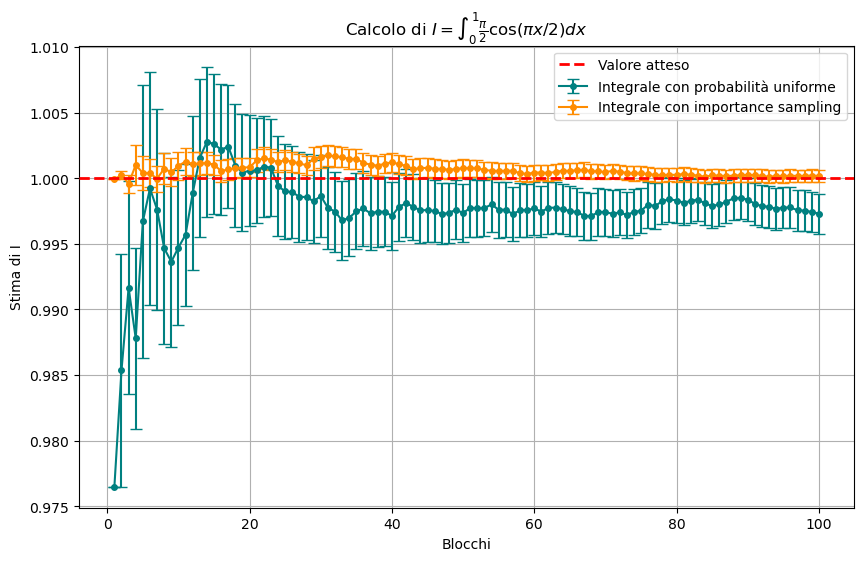

In [30]:
M=100000
N=100
L=int(M/N)

# 1. Leggo il file. 
cos, err_cos = np.loadtxt('cosine_data.txt', unpack = True)
imp, err_imp = np.loadtxt('importance.txt', unpack = True)
print(f"Incertezza finale per p(x) uniforme: {err_cos[-1]:.3f}")
print(f"Incertezza finale con importance sampling: {err_imp[-1]:.4f}")

r = np.arange(N)

plt.figure(figsize=(10, 6))

plt.title(r"Calcolo di $I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx$")
plt.axhline(1.00, color='red', linestyle='--', linewidth = 2, zorder = 10, label = 'Valore atteso')
plt.errorbar(r+1, cos ,yerr=err_cos,  fmt='o-', color='teal', ecolor='teal', elinewidth=1.5, capsize=4, markersize=4, label=r'Integrale con probabilità uniforme')
plt.errorbar(r+1, imp ,yerr=err_imp, fmt='o-', color='darkorange', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label=r'Integrale con importance sampling')
plt.xlabel('Blocchi')
plt.ylabel('Stima di I')
plt.legend()
plt.grid(True)
plt.show()


Possiamo osservare come l'incertezza associata al calcolo dell'integrale svolto con importance sampling sia $4$ volte inferiore a quella relativa al calcolo con distribuzione di probabilità uniforme.

Questo valoe trova una giustificazione teorica: la varianza calcolata per una distribuzione uniforme, dato valore di aspettazione di $I=1$ è $$\sigma_{unif}^2 = \int_0^1g(x)^2dx - I^2 = \frac{\pi^2}{8} - 1 \approx 0.23$$

Per l'importanca sampling, invece, la varianza teorica è $$\sigma_{imp}^2 = \int_0^1\left[\frac{g(x)}{d(x)}\right]^2d(x)dx - I^2 \approx 0.014$$
L'incertezza associata al calcolo dell'integrale è $E = \frac{\sigma}{\sqrt{M}}$, con $M$ numero totale dei lanci e $\sigma^2$ calcolato come sopra. Poiché per entrambi i calcoli $M$ è uguale, il rapporto tra le due incertezze sarà dato da $$\sqrt{\frac{\sigma_{unif}^2}{\sigma_{imp}^2}} \approx \sqrt{16} = 4$$.

## <span style="color:blue">  Exercise 02.2 </span>

Per l'esperimento sono stati utilizzati i seguenti valori:
- $M = 10000$: random walks
- $N = 100$: blocchi 
- $L = M/N = 100$: random walks in ciascun blocco
- $t_{max} = 100$: numero di passi per ciascun random walk


## <span style="color:black">  Random walk discreto </span>

Ad ogni passo $t$, la posizione viene aggiornata estraendo 1 solo numero casuale r, compreso tra 0 e 5. Su di esso vengono compiute due operazioni:
- $r/2$ che, essendo una divisione intera, restituisce un intero che identifica l'asse su cui viene compiuto lo spostamento (0, 1 o 2);
- $1-2(r\%2)$, che restituisce $+1$ o $-1$, identificando il verso dello spostamento.

Dopo ogni passo $t$ viene calcolata la distanza quadratica dall'origine $ |\vec{r}_t|^2_{RW}$, che viene passata alla classe analizzatrice.
Questa operazione viene ripetuta per tutti gli $M$ random walk simulati. 

Per ogni blocco, la media $\langle |\vec{r}_N|^2 \rangle_{RW}$ è calcolata in funzione del passo $t$ come $\frac{1}{L}\sum_{i=1}^L\langle |\vec{r}_t|^2 \rangle_{RW}$. Ne viene calcolata la deviazione standard $\sigma_{quad}$. 

In ultimo, si adempie alla richiesta calcolando $$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}} = \sqrt{\frac{1}{L}\sum_{i=1}^L\langle |\vec{r}_t|^2 \rangle_{RW}},$$ la cui deviazione standard è calcolata propagando l'errore sul quadrato: $$\sigma = \frac{\sigma_{quad}}{2\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}}.$$




In [31]:
from scipy.stats import chi2
from scipy.optimize import curve_fit

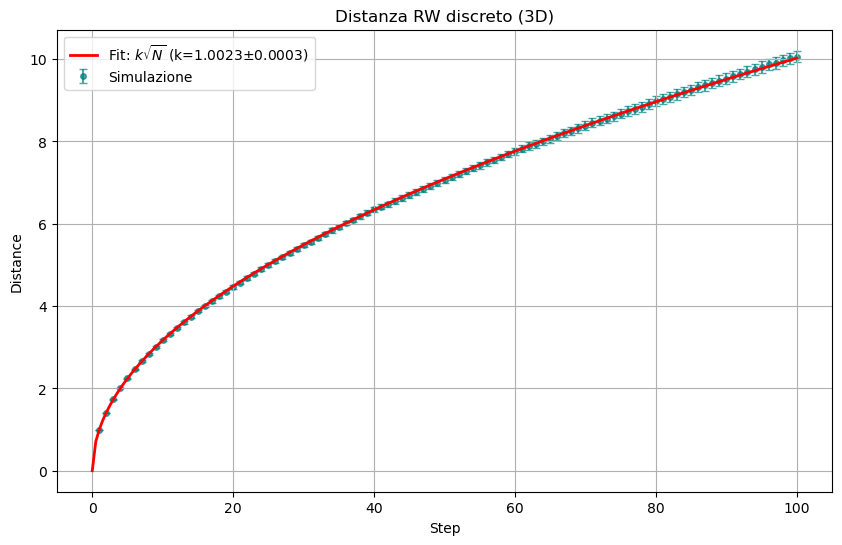

In [32]:
N=100
s=1

x, y = np.loadtxt('Discrete.txt', unpack = True)

r = np.arange(1, N+1)

def fit_func(N, k):
    return k * np.sqrt(N)

popt, pcov = curve_fit(fit_func, r, x)
k_best = popt[0]
k_error = np.sqrt(pcov[0, 0])
t_fit = np.linspace(0, 100, 200)

plt.figure(figsize=(10, 6))

plt.plot(t_fit, fit_func(t_fit, k_best), color='red', label=f'Fit: $k\\sqrt{{N}}$ (k={k_best:.4f}±{k_error:.4f})', linewidth=2)
plt.errorbar(r,x,yerr=y, fmt='o', markersize=4, capsize=3, 
             linestyle='none', color='teal', alpha=0.7, zorder = 1, label='Simulazione')
plt.xlabel('Step')
plt.ylabel('Distance')
plt.grid(True)
plt.title("Distanza RW discreto (3D)")
plt.legend()
plt.show()
  


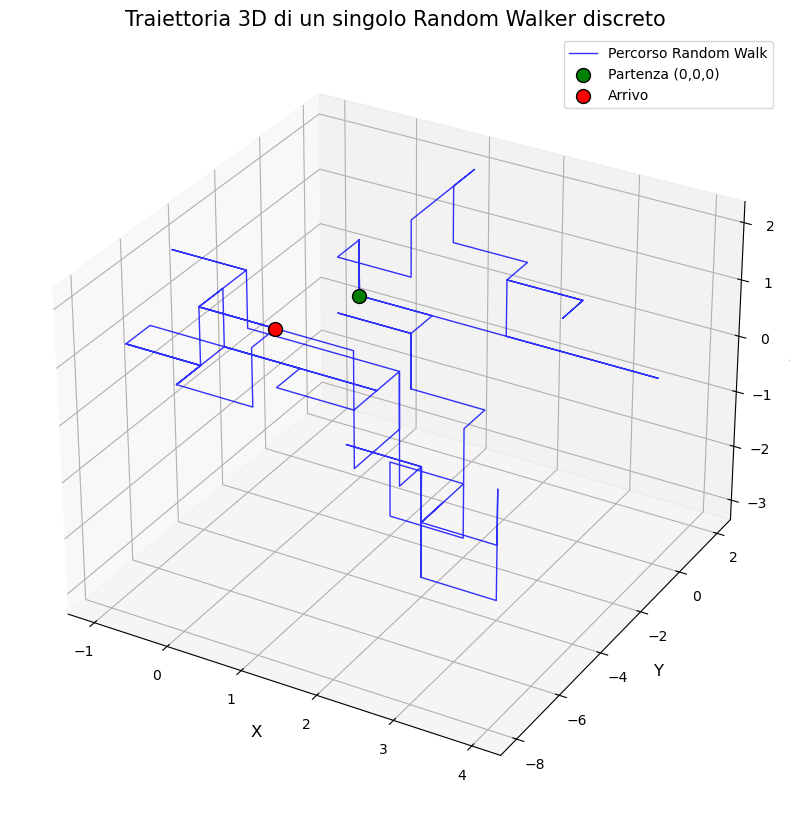

In [33]:
x, y, z = np.loadtxt('Path_Discrete.txt', usecols = (0, 1, 2), unpack = True)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=1, alpha=0.8, color='blue', label='Percorso Random Walk')
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Partenza (0,0,0)', edgecolors='black')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='Arrivo', edgecolors='black')
ax.set_title('Traiettoria 3D di un singolo Random Walker discreto', fontsize=15)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.show()

## <span style="color:black">  Random walk continuo </span>

Per il random walk continuo sono stati estratti due numeri casuali:
- $\phi \in [0, 2\pi]$;
- $ x = \cos(\theta) \in [-1, 1]$.

Infatti, per campionare correttamente l'angolo solido è necessario campionare $\theta$ secondo la distribuzione di probabilità $p(\theta) = \frac{1}{2}\sin(\theta)$, con $\theta \in [0, \pi]$. Con il metodo della trasformata inversa, avendo calcolato la funzione cumulativa $P_{\theta}(\theta) = \frac{1}{2}(1-\cos(\theta))$ e avendola posta uguale ad una variabile $y \in [0, 1]$, si ottiene $\theta = \arccos(1 - 2y)$. 

Poiché $(1-2y)$, con $y \in [0, 1]$ spazza un range $[-1, 1]$, ho scelto di estrarre direttaemente $x \in [-1, 1]$ e ricostruire $\theta = \arccos(x)$.

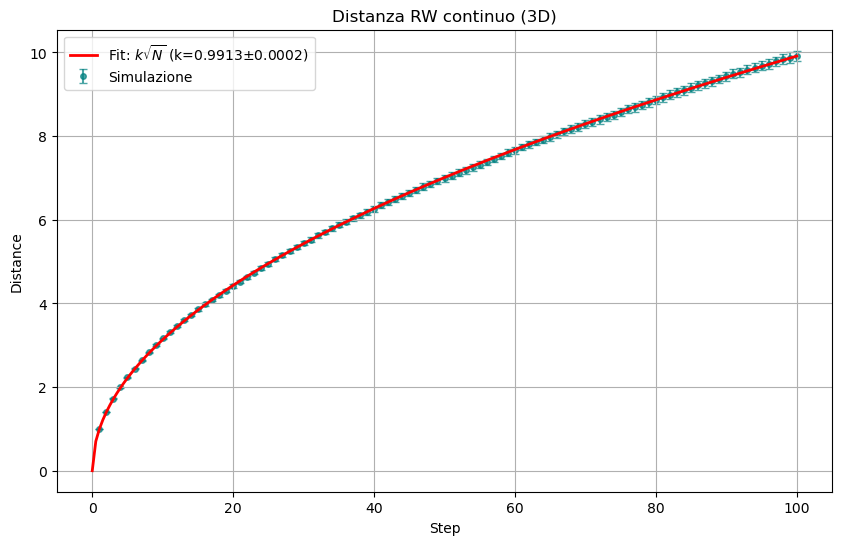

In [34]:
x, y = np.loadtxt('Continuum.txt', unpack = True)

r = np.arange(1, N+1)
def fit_func(N, k):
    return k * np.sqrt(N)

popt, pcov = curve_fit(fit_func, r, x)
k_best = popt[0]
k_error = np.sqrt(pcov[0, 0])
t_fit = np.linspace(0, 100, 200)

plt.figure(figsize=(10, 6))

plt.plot(t_fit, fit_func(t_fit, k_best), color='red', label=f'Fit: $k\\sqrt{{N}}$ (k={k_best:.4f}±{k_error:.4f})', linewidth=2)
plt.errorbar(r,x,yerr=y, fmt='o', markersize=4, capsize=3, 
             linestyle='none', color='teal', alpha=0.7, zorder = 1, label='Simulazione')
plt.xlabel('Step')
plt.ylabel('Distance')
plt.grid(True)
plt.title("Distanza RW continuo (3D)")
plt.legend()
plt.show()
  


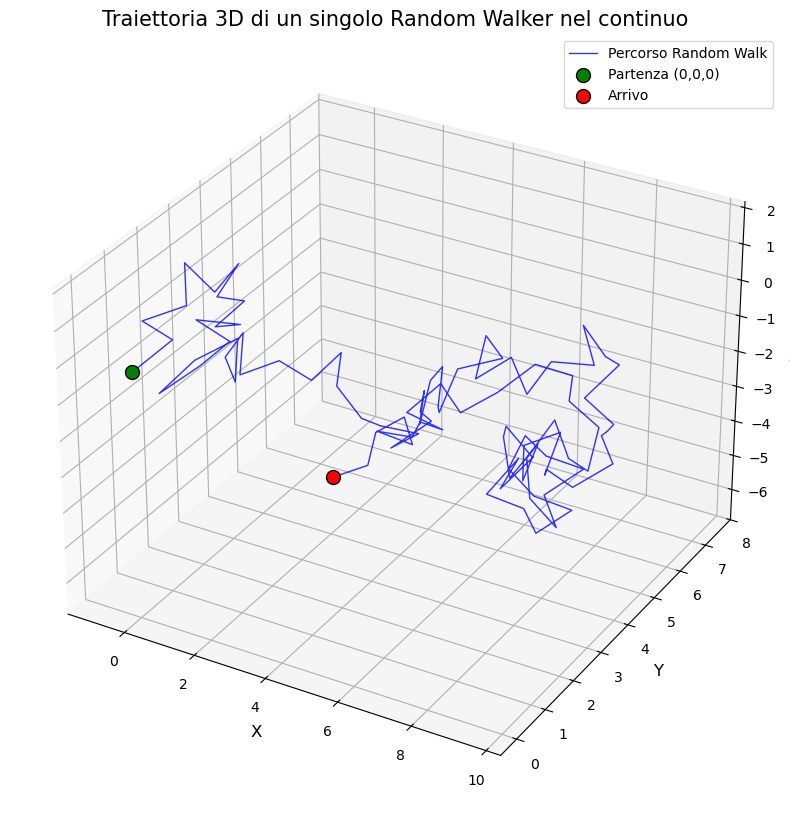

In [35]:
x, y, z = np.loadtxt('Path_Continuum.txt', usecols = (0, 1, 2), unpack = True)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=1, alpha=0.8, color='blue', label='Percorso Random Walk')
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Partenza (0,0,0)', edgecolors='black')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='Arrivo', edgecolors='black')
ax.set_title('Traiettoria 3D di un singolo Random Walker nel continuo', fontsize=15)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.show()

Possiamo osservare che i random walk esibiscono un comportamento diffusivo. Entrambe le evoluzioni di $\sqrt{\langle|\vec{r}_N|^2\rangle}$ sono infatti compatibili con una curva $a\sqrt N$, con $a\approx 1$. Questo è in accordo con il modello teorico che prevede un andamento della varianza $\langle|\vec{r}_N|^2\rangle = Na^2$.

Questa relazione è ricavata direttamente dall'equazione di diffusione in 3 dimensioni $$\frac{\partial p(\vec{r}, t)}{\partial t} = D\nabla^2p(\vec{r}, t),$$

risolvendo la quale otteniamo la distribuzione continua $$p(\vec{r}, t) = \frac{1}{(4\pi D t)^{3/2}}\exp\left[-\frac{|\vec{r}|^2}{4Dt}\right].$$

Questa espressione è prodotto di 3 gaussiane, una per ogni direzione spaziale. Dal momento che l'andamento su ciascuna di queste è indipendente, la varianza è la somma del contributo lungo ogni asse:

$$\langle|\vec{r}|^2\rangle = \langle x^2 \rangle + \langle y^2 \rangle + \langle z^2 \rangle = 6Dt.$$


Possiamo anche modellizzare il random walk come $\vec{S}_N = \sum_{t=1}^{N}\vec{s}_t$, con $\vec{s}_t$ singolo step.

Per un random walk che parta dall'origine abbiamo $$\langle \vec{S}_N \rangle = 0, \,\,\,\,\, \langle |\vec{S}_N|^2 \rangle = \sum_{t=1}^N \langle |\vec{s}_t|^2 \rangle = Na^2.$$

Per il teorema del limite centrale, per $N\rightarrow +\infty$, la densità di probabilità per la posizione del random walk converge a una distribuzione limite $$P(\vec{S}_N) \xrightarrow{N \to \infty} \left (\frac{3}{2\pi N a^2}\right)^{3/2} \exp\left[ -\frac{3|\vec{S}_N|^2}{2 N a^2} \right].$$

Confrontando la distribuzione di probabilità continua con il limite discreto, e osservando che nella modellizzazione discreta $t = N\tau$, otteniamo la relazione $$Na^2 = 6DN\tau \rightarrow D = \frac{a^2}{6\tau}.$$




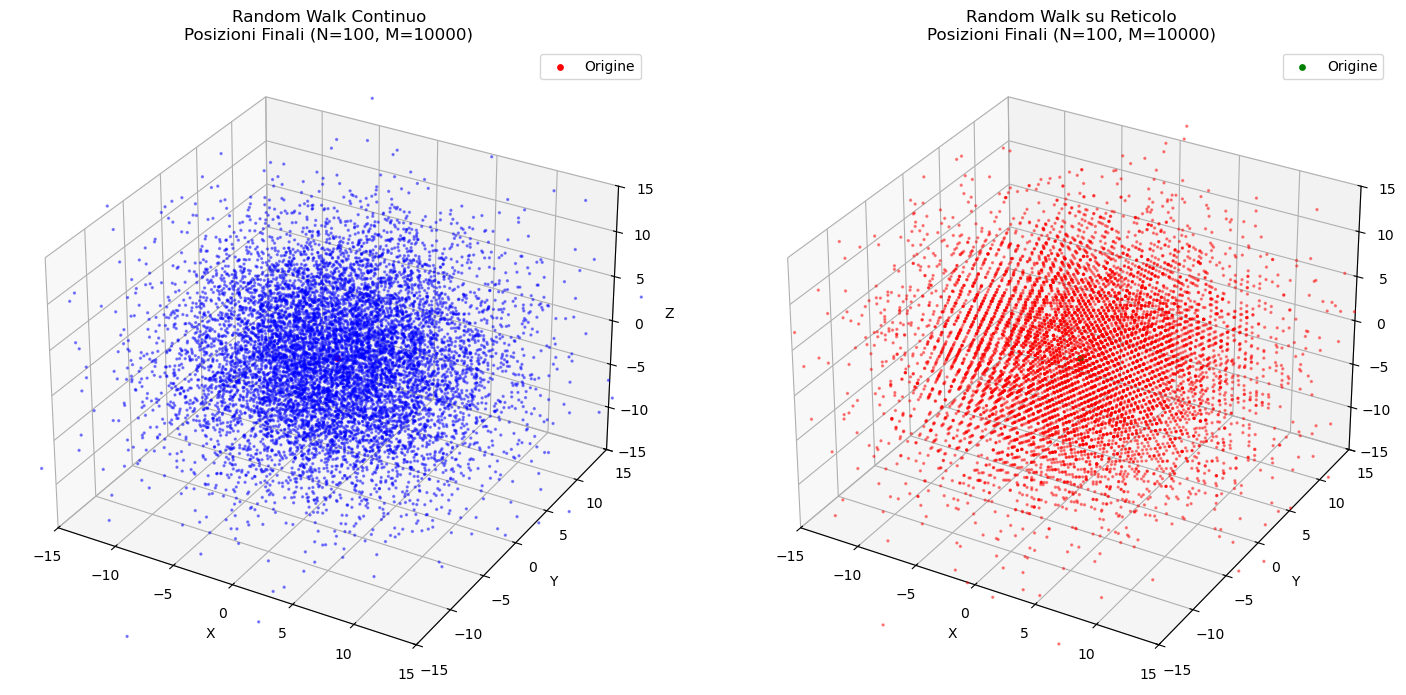

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': '3d'})

# Randomw walk continuo
data_c = np.loadtxt('Final_Positions_C.txt')
x_c, y_c, z_c = data_c[:,0], data_c[:,1], data_c[:,2]

axes[0].scatter(x_c, y_c, z_c, c='b', marker='o', s=2, alpha=0.4)
axes[0].scatter(0, 0, 0, c = 'r', s=15, zorder = 1, label = 'Origine')
axes[0].set_title('Random Walk Continuo\nPosizioni Finali (N=100, M=10000)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_zlabel('Z')

# Forzo le stesse proporzioni sugli assi
max_range_c = np.array([x_c.max()-x_c.min(), y_c.max()-y_c.min(), z_c.max()-z_c.min()]).max() / 2.0
mid_x_c = (x_c.max()+x_c.min()) * 0.5
mid_y_c = (y_c.max()+y_c.min()) * 0.5
mid_z_c = (z_c.max()+z_c.min()) * 0.5
axes[0].set_xlim(-15, 15)
axes[0].set_ylim(-15, 15)
axes[0].set_zlim(-15, 15)
axes[0].legend()


# Random walk discreto
data_d = np.loadtxt('Final_Positions_D.txt')
x_d, y_d, z_d = data_d[:,0], data_d[:,1], data_d[:,2]

axes[1].scatter(x_d, y_d, z_d, c='r', marker='o', s=2, alpha=0.4)
axes[1].scatter(0, 0, 0, c = 'g', s=15, label = 'Origine')
axes[1].set_title('Random Walk su Reticolo\nPosizioni Finali (N=100, M=10000)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_zlabel('Z')
axes[1].set_xlim(-15, 15)
axes[1].set_ylim(-15, 15)
axes[1].set_zlim(-15, 15)
axes[1].legend()

plt.tight_layout()
plt.show()

Plottando le posizioni finali dei 10000 RWs, possiamo notare come queste siano distribuite secondo la gaussiana tridimensionale centrata intorno all'origine prevista dalla teoria $$P(\vec{S}_N) = \left (\frac{3}{2\pi N a^2}\right)^{3/2} \exp\left[ -\frac{3|\vec{S}_N|^2}{2 N a^2} \right].$$
Il valor medio della posizione finale $\langle \vec{S}_N \rangle = 0$, ma la dispersione (varianza) è chiaramente non nulla.

Possiamo anche notare che, nonostante entrambi i tipi di RW esibiscano lo stesso comportamento in termini di distanza quadratica media, $N = 100$ passi non sono sufficienti per azzerare le differenze topologiche tra RW continuo e RW discreto. Le posizioni finali dei RW discreti, infatti, risultano distribuite su direttrici ben precise, che rispecchiano la natura discreta dei percorsi. La visualizzazione 3D ci permette di osservare piani paralleli di punti orientati in direzioni diverse, che ricordano le diverse possibili scelte degli indici di Miller utilizzati nella descrizione dei reticoli atomici. Visivamente, questo effetto è acuito dal fatto che essendo $N$ pari, la somma delle coordinate $x + y + z$ della posizione finale deve necessariamente essere pari. Questo fa 'sì che i punti si distribuiscano secondo un sottoreticolo FCC, in cui la distanza minima tra i punti è $\sqrt2$ invece che $1$.